In [2]:
import pandas as pd 
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_column', 50)
pd.set_option('display.max_colwidth',80)

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('../data/raw/Developer_survey_2025.csv',low_memory=False)

print(f"shape:{df.shape}")
print(f'Last 5 column names:{list(df.columns[5:])}')

shape:(49191, 172)
Last 5 column names:['EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersonal', 'Country', 'Curre

In [6]:
target_col = 'ConvertedCompYearly'
print(f'Does the column actually exist: {target_col in df.columns}')

Does the column actually exist: True


In [10]:
 # how many rows have a salary value?
salary_available  = df[target_col].notnull().sum()
salary_missing = df[target_col].isna().sum()

print(f'Rows with salary: {salary_available}')
print(f' Rows without salary: {salary_missing}')
print( f'coverage:{ salary_available/len(df)*100:.1f}%')

Rows with salary: 23947
 Rows without salary: 25244
coverage:48.7%


In [11]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

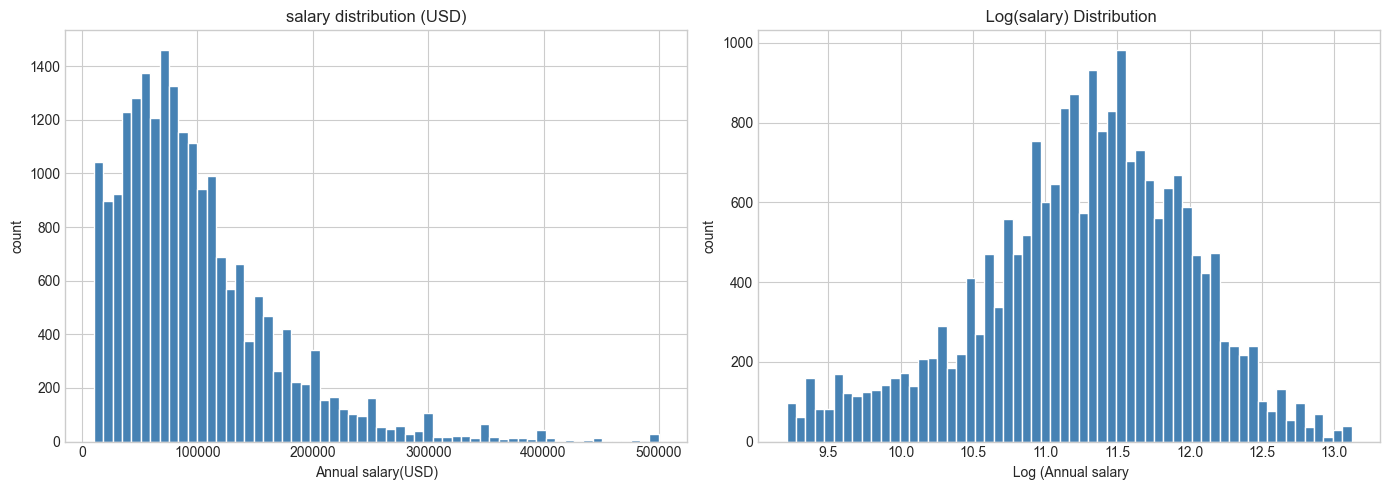

median salary: $81,870
mean salary:$98,572


In [12]:
#filtering - picking rows with salary range btn range of 10,000 - 500,000
salary_df = df[df[target_col].between(10000,500_000)]

fig, axes = plt.subplots(1,2, figsize = (14,5))
#raw distribution.

axes[0].hist(salary_df[target_col], bins=60,color='steelblue', edgecolor = 'white')
axes[0].set_title('salary distribution (USD)')
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('count')

# log_scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60,color='steelblue', edgecolor = 'white')
axes[1].set_title(' Log(salary) Distribution')
axes[1].set_xlabel(' Log (Annual salary')
axes[1].set_ylabel('count')


plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()

print(f"median salary: ${salary_df[target_col].median():,.0f}")
print(f"mean salary:${salary_df[target_col].mean():,.0f}")





In [8]:
features = ['Country','YearsCode','EdLevel','Employment','LanguageHaveWorkedwith']

for col in features:
    if col in df.columns:
        missing_pct = df[col].isna().mean()*100
        unique_count = df[col].nunique()

        print(f"column:{col}")
        print(f"Missing:{missing_pct}%")
        print(f"Unique values in {col}:{unique_count}")
        print("Top 5 values")
        print(df[col].value_counts().head().to_string)
        print()



column:Country
Missing:27.96039926002724%
Unique values in Country:177
Top 5 values
<bound method Series.to_string of Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Name: count, dtype: int64>

column:YearsCode
Missing:12.500254111524466%
Unique values in YearsCode:78
Top 5 values
<bound method Series.to_string of YearsCode
10.0    3108
15.0    2540
20.0    2497
5.0     2267
8.0     2113
Name: count, dtype: int64>

column:EdLevel
Missing:2.118273667947389%
Unique values in EdLevel:8
Top 5 values
<bound method Series.to_string of EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20278
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12589
Some col

C:\Users\Njeri.Maina\AppData\Local\Temp\ipykernel_7708\1663563468.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


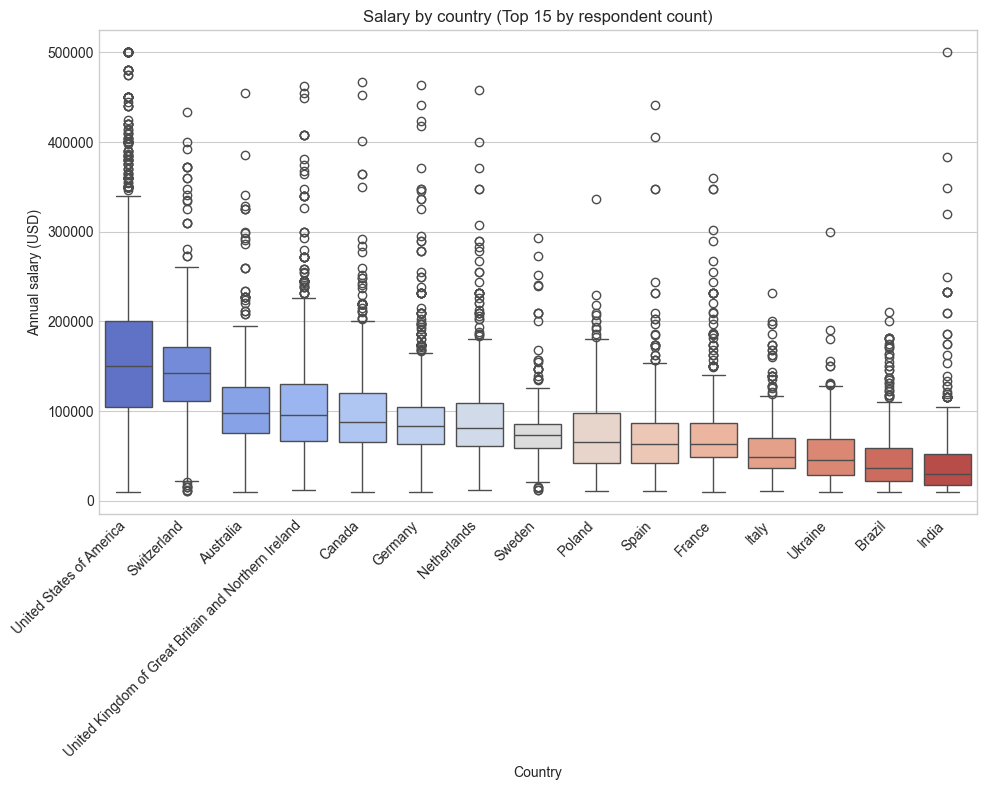

In [20]:
#visualizing  salary by country
# only keep rows with salary
df_sal = df[df[target_col].between(10_000, 500_000)].copy()
 
top_countries = df_sal['Country'].value_counts().head(15).index
country_data = df_sal[df_sal['Country'].isin(top_countries)]


plt.figure(figsize=(10, 8))
order= country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index
 
sns.boxplot(
    data=country_data,
    x = 'Country', y= target_col,
    order = order,
    palette='coolwarm'
)
 
plt.xticks(rotation=45, ha='right')
plt.title('Salary by country (Top 15 by respondent count)')
plt.ylabel('Annual salary (USD)')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png', dpi=300)
 
plt.show()



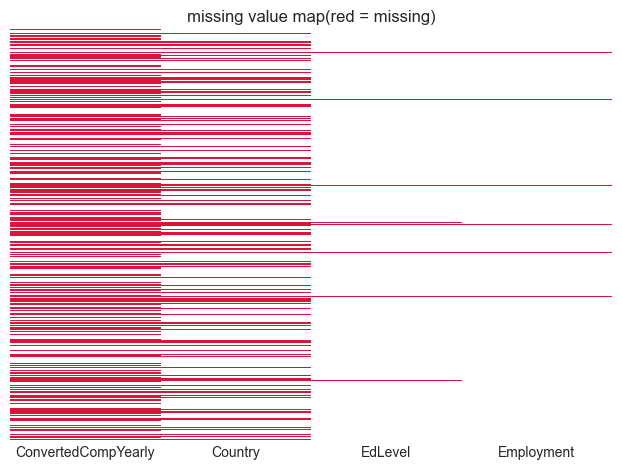

In [10]:
# missing values heatmap
selected_cols = ["ConvertedCompYearly", 'Country','YearCode','EdLevel','Employment']
available_col = [c for c in selected_cols if c in df.columns]

missing_df = df[available_col].isna()

plt.Figure(figsize=(10, 6))
sns.heatmap(missing_df.sample(min(1000,len(df)), random_state=42),
            cbar=False, yticklabels=False,
            cmap=['white','crimson']
            )
plt.title('missing value map(red = missing)')
plt.tight_layout()
plt.show()


In [8]:
df['EdLevel'].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str

In [4]:
import os
import sys

# addding /src to path to allow us to import our modules
sys.path.insert(0,os.path.dirname('..src/'))

from preprocessing import  load_and_clean, get_feature_column,TARGET 

df = load_and_clean('../data/raw/developers_survey_2025.csv')
df. to_csv('../data/cleaned/preprocessed_data.csv', index=False)

ModuleNotFoundError: No module named 'preprocessing'

In [5]:
df['OrgSize'].unique()

<ArrowStringArray>
[                                '20 to 99 employees',
                               '500 to 999 employees',
                                                  nan,
                           '10,000 or more employees',
                             'Less than 20 employees',
                           '5,000 to 9,999 employees',
                               '100 to 499 employees',
                           '1,000 to 4,999 employees',
                                       'I don’t know',
 'Just me - I am a freelancer, sole proprietor, etc.']
Length: 10, dtype: str

In [6]:
df_subset = pd.read_csv('../data/cleaned/processed-data.csv')

In [7]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 21203 entries, 0 to 21202
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 21203 non-null  str    
 1   YearsCode               21136 non-null  float64
 2   EdLevel                 21203 non-null  str    
 3   Employment              21203 non-null  str    
 4   DevType                 21203 non-null  str    
 5   OrgSize                 18944 non-null  str    
 6   RemoteWork              18863 non-null  str    
 7   WorkExp                 20955 non-null  float64
 8   Industry                20585 non-null  str    
 9   Age                     21203 non-null  str    
 10  ICorPM                  18688 non-null  str    
 11  DatabaseHaveWorkedWith  16608 non-null  str    
 12  PlatformHaveWorkedWith  16252 non-null  str    
 13  ToolCountWork           18086 non-null  float64
 14  log_salary              21203 non-null  float64
 